# Fase 1 — Sección 3: Análisis de Calidad de Datos
**Proyecto Final — Gestión de Datos (UAX 2025/2026)**

Diagnóstico sistemático y formal de la calidad de los datos en las 17 tablas operacionales.
A diferencia de la Sección 2 (exploración narrativa), aquí aplicamos criterios definidos
sobre todas las tablas de forma homogénea.

| Dimensión | Descripción |
|-----------|-------------|
| **3.1 Nulos** | Columnas con valores nulos y su porcentaje |
| **3.2 Duplicados** | Registros exactos y duplicados lógicos |
| **3.3 Formatos** | Teléfonos, emails, códigos postales, fechas |
| **3.4 Rangos numéricos** | Precios, costes, cantidades, márgenes |
| **3.5 Integridad referencial** | Verificación de todas las FKs |
| **3.6 Consistencia entre tablas** | Totales, márgenes, cruces |
| **3.7 Consistencia temporal** | Coherencia de fechas entre tablas |
| **3.8 Score de calidad** | Puntuación resumen por tabla |

---

## Configuración

In [1]:
PALETA = {
    'ERP'       : '#2C6FBF',
    'CRM'       : '#27A06B',
    'Logistica' : '#E07B2A',
    'Postventa' : '#8B4BB8'
}

SISTEMAS = {
    'ERP'       : ['product', 'central_product', 'brand', 'category',
                   'sale', 'sale_item', 'offer', 'product_offer', 'store', 'inventory'],
    'CRM'       : ['customer', 'city_zone'],
    'Logistica' : ['warehouse', 'warehouse_location', 'central_inventory'],
    'Postventa' : ['return_item', 'return_reason']
}

TODAS_LAS_TABLAS = [t for ts in SISTEMAS.values() for t in ts]

print('Constantes cargadas.')

Constantes cargadas.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
import warnings
import re

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

PROJECT_ROOT = Path(r'C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd')
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Librerias importadas correctamente.')
print(f'Figuras en: {FIGURES_DIR}')

Librerias importadas correctamente.
Figuras en: C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd\reports\figures


In [3]:
DB_USER     = 'postgres'
DB_PASSWORD = 'pimpum.postgre'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'saleshealth'

DATABASE_URL = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    version = conn.execute(text('SELECT version()')).fetchone()[0]

print(f'Conexion establecida. PostgreSQL: {version.split(",")[0]}')

Conexion establecida. PostgreSQL: PostgreSQL 18.3 on x86_64-windows


In [4]:
def query(sql, params=None):
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn, params=params)

def execute(sql, params=None):
    with engine.begin() as conn:
        return conn.execute(text(sql), params or {}).rowcount

def nulos_tabla(nombre_tabla):
    columnas = query(
        "SELECT column_name FROM information_schema.columns "
        "WHERE table_schema='public' AND table_name=:t ORDER BY ordinal_position",
        {'t': nombre_tabla}
    )['column_name'].tolist()
    partes    = [f'COUNT(*) FILTER (WHERE "{c}" IS NULL) AS "{c}"' for c in columnas]
    resultado = query(f"SELECT {', '.join(partes)} FROM {nombre_tabla}")
    total     = query(f"SELECT COUNT(*) AS total FROM {nombre_tabla}")['total'].iloc[0]
    df        = resultado.T.reset_index()
    df.columns = ['columna', 'nulos']
    df['total']     = total
    df['pct_nulos'] = (df['nulos'] / total * 100).round(2)
    return df

print('Funciones helper definidas.')

Funciones helper definidas.


---
## 3.1 — Análisis de nulos
Conteo de valores nulos por tabla y columna. Distinguimos entre nulos esperados
(campos opcionales por diseño) y nulos problemáticos (campos que deberían tener valor).

In [5]:
# ── Nulos por tabla (resumen global) ─────────────────────────────────────────
resumen_nulos = []

for tabla in TODAS_LAS_TABLAS:
    df_n = nulos_tabla(tabla)
    total     = df_n['total'].iloc[0] if len(df_n) > 0 else query(f'SELECT COUNT(*) AS total FROM {tabla}')['total'].iloc[0]
    col_nulas = len(df_n[df_n['nulos'] > 0])
    max_pct   = df_n['pct_nulos'].max() if len(df_n[df_n['nulos'] > 0]) > 0 else 0
    sistema   = next((s for s, ts in SISTEMAS.items() if tabla in ts), '?')
    resumen_nulos.append({
        'tabla': tabla, 'sistema': sistema,
        'registros': total, 'columnas_con_nulos': col_nulas, 'max_pct_nulos': max_pct
    })

df_resumen_nulos = pd.DataFrame(resumen_nulos).sort_values('max_pct_nulos', ascending=False)

print('=' * 68)
print('  RESUMEN DE NULOS POR TABLA')
print('=' * 68)
print(f'  {"TABLA":<22} {"SISTEMA":<12} {"REGISTROS":>10}  {"COLS CON NULOS":>14}  {"MAX %":>7}')
print('-' * 68)
for _, row in df_resumen_nulos.iterrows():
    alerta = '  ⚠' if row['max_pct_nulos'] > 10 else ''
    print(f'  {row["tabla"]:<22} {row["sistema"]:<12} {int(row["registros"]):>10,}  '
          f'{int(row["columnas_con_nulos"]):>14}  {row["max_pct_nulos"]:>6.1f}%{alerta}')
print('=' * 68)

  RESUMEN DE NULOS POR TABLA
  TABLA                  SISTEMA       REGISTROS  COLS CON NULOS    MAX %
--------------------------------------------------------------------
  sale_item              ERP              42,555               1   100.0%  ⚠
  brand                  ERP                  29               1    27.6%  ⚠
  city_zone              CRM                  42               1     2.4%
  product                ERP                  50               0     0.0%
  category               ERP                   6               0     0.0%
  sale                   ERP              20,000               0     0.0%
  offer                  ERP                   1               0     0.0%
  product_offer          ERP                   6               0     0.0%
  central_product        ERP                  50               0     0.0%
  store                  ERP                  20               0     0.0%
  inventory              ERP               1,000               0     0.0%
  custom

In [6]:
# ── Detalle de nulos en tablas con columnas nulas ─────────────────────────────
tablas_con_nulos = df_resumen_nulos[df_resumen_nulos['columnas_con_nulos'] > 0]['tabla'].tolist()

print(f'Tablas con al menos una columna nula: {len(tablas_con_nulos)}')
print()

for tabla in tablas_con_nulos:
    df_n = nulos_tabla(tabla)
    df_n_filt = df_n[df_n['nulos'] > 0].sort_values('pct_nulos', ascending=False)
    if len(df_n_filt) == 0:
        continue
    sistema = next((s for s, ts in SISTEMAS.items() if tabla in ts), '?')
    print(f'  [{sistema}] {tabla}')
    print(f'  {"COLUMNA":<25} {"NULOS":>8}  {"% TOTAL":>8}')
    print('  ' + '-' * 44)
    for _, row in df_n_filt.iterrows():
        alerta = '  ⚠' if row['pct_nulos'] > 10 else ''
        print(f'  {row["columna"]:<25} {int(row["nulos"]):>8,}  {row["pct_nulos"]:>7.2f}%{alerta}')
    print()

Tablas con al menos una columna nula: 3

  [ERP] sale_item
  COLUMNA                      NULOS   % TOTAL
  --------------------------------------------
  offer_id                    42,547    99.98%  ⚠

  [ERP] brand
  COLUMNA                      NULOS   % TOTAL
  --------------------------------------------
  website                          8    27.59%  ⚠

  [CRM] city_zone
  COLUMNA                      NULOS   % TOTAL
  --------------------------------------------
  zone_orientation                 1     2.38%



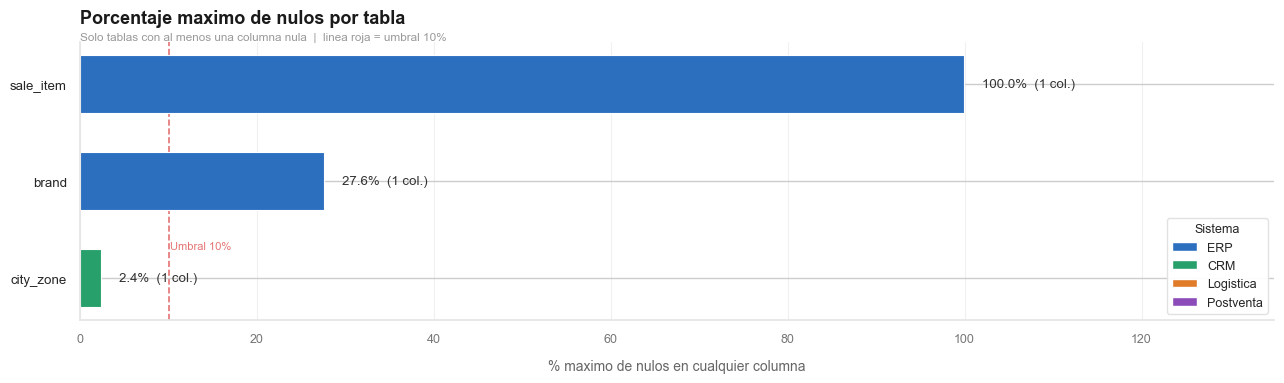

In [7]:
# ── Grafico: columnas con nulos por tabla ─────────────────────────────────────
df_plot = df_resumen_nulos[df_resumen_nulos['columnas_con_nulos'] > 0].sort_values('max_pct_nulos', ascending=True)
color_por_sistema = [PALETA[s] for s in df_plot['sistema']]

fig, ax = plt.subplots(figsize=(13, max(4, len(df_plot) * 0.55)))
fig.patch.set_facecolor('white')

bars = ax.barh(df_plot['tabla'], df_plot['max_pct_nulos'],
               color=color_por_sistema, edgecolor='white', linewidth=0.8, height=0.6)

max_v = df_plot['max_pct_nulos'].max()
for bar, val, cols in zip(bars, df_plot['max_pct_nulos'], df_plot['columnas_con_nulos']):
    ax.text(bar.get_width() + max_v * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%  ({int(cols)} col.)',
            va='center', ha='left', fontsize=9.5, color='#333333')

# Linea de referencia al 10%
ax.axvline(10, color='#E57373', linewidth=1.2, linestyle='--', zorder=0)
ax.text(10.2, 0.3, 'Umbral 10%', fontsize=8, color='#E57373')

ax.set_title('Porcentaje maximo de nulos por tabla', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01, 'Solo tablas con al menos una columna nula  |  linea roja = umbral 10%',
        transform=ax.transAxes, fontsize=8.5, color='#999999')
ax.set_xlabel('% maximo de nulos en cualquier columna', fontsize=10, color='#666666', labelpad=10)
ax.tick_params(axis='y', labelsize=9.5)
ax.tick_params(axis='x', labelsize=9, colors='#777777')
ax.set_xlim(0, max_v * 1.35)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='#F0F0F0', linewidth=0.8)

legend_elements = [Patch(facecolor=PALETA[s], label=s) for s in PALETA]
ax.legend(handles=legend_elements, title='Sistema', title_fontsize=9,
          fontsize=9, loc='lower right', frameon=True, framealpha=0.95, edgecolor='#E0E0E0')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_nulos_por_tabla.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## 3.2 — Análisis de duplicados

In [8]:
# ── Duplicados exactos por tabla ──────────────────────────────────────────────
print('=' * 58)
print('  DUPLICADOS EXACTOS POR TABLA')
print('=' * 58)
print(f'  {"TABLA":<22} {"REGISTROS":>10}  {"DUPLICADOS":>11}  {"% TOTAL":>8}')
print('-' * 58)

resultados_dup = []
for tabla in TODAS_LAS_TABLAS:
    total = query(f'SELECT COUNT(*) AS n FROM {tabla}')['n'].iloc[0]
    unicos = query(f'SELECT COUNT(*) AS n FROM (SELECT DISTINCT * FROM {tabla}) t')['n'].iloc[0]
    dups   = total - unicos
    pct    = dups / total * 100 if total > 0 else 0
    alerta = '  ⚠' if dups > 0 else ''
    print(f'  {tabla:<22} {int(total):>10,}  {int(dups):>11,}  {pct:>7.2f}%{alerta}')
    resultados_dup.append({'tabla': tabla, 'total': total, 'duplicados': dups, 'pct': pct})

print('=' * 58)
df_dup = pd.DataFrame(resultados_dup)
total_dup = df_dup['duplicados'].sum()
print(f'\nTotal duplicados exactos en toda la BD: {int(total_dup):,}')

  DUPLICADOS EXACTOS POR TABLA
  TABLA                   REGISTROS   DUPLICADOS   % TOTAL
----------------------------------------------------------
  product                        50            0     0.00%
  central_product                50            0     0.00%
  brand                          29            0     0.00%
  category                        6            0     0.00%
  sale                       20,000            0     0.00%
  sale_item                  42,555            0     0.00%
  offer                           1            0     0.00%
  product_offer                   6            0     0.00%
  store                          20            0     0.00%
  inventory                   1,000            0     0.00%
  customer                    5,750            0     0.00%
  city_zone                      42            0     0.00%
  warehouse                       1            0     0.00%
  warehouse_location             40            0     0.00%
  central_inventory      

In [9]:
# ── Duplicados logicos en customer ────────────────────────────────────────────
# Clientes con mismo nombre + apellido (ya analizado en Seccion 2, confirmamos aqui)
df_dup_customer = query("""
    SELECT first_name, last_name, COUNT(*) AS ocurrencias
    FROM customer
    GROUP BY first_name, last_name
    HAVING COUNT(*) > 1
    ORDER BY ocurrencias DESC
""")

total_afectados = query("""
    SELECT COUNT(*) AS n FROM customer
    WHERE (first_name, last_name) IN (
        SELECT first_name, last_name FROM customer
        GROUP BY first_name, last_name HAVING COUNT(*) > 1
    )
""")['n'].iloc[0]

print('=' * 58)
print('  DUPLICADOS LOGICOS — customer (nombre + apellido)')
print('=' * 58)
print(f'  Combinaciones nombre+apellido repetidas : {len(df_dup_customer):,}')
print(f'  Clientes afectados                      : {int(total_afectados):,}')
print(f'  Conclusion: NO es error — customer_id es unico')
print('=' * 58)

  DUPLICADOS LOGICOS — customer (nombre + apellido)
  Combinaciones nombre+apellido repetidas : 1,060
  Clientes afectados                      : 2,930
  Conclusion: NO es error — customer_id es unico


---
## 3.3 — Validación de formatos

In [10]:
# ── Telefonos ─────────────────────────────────────────────────────────────────
df_tel = query("SELECT phone FROM customer WHERE phone IS NOT NULL")
df_tel['longitud'] = df_tel['phone'].str.len()
dist_tel = df_tel['longitud'].value_counts().sort_index()

total_tel    = len(df_tel)
correctos    = df_tel[df_tel['longitud'] == 13]
incorrectos  = df_tel[df_tel['longitud'] != 13]

print('=' * 52)
print('  VALIDACION TELEFONOS — customer.phone')
print('  Formato esperado: 13 caracteres')
print('=' * 52)
print(f'  {"Longitud":<12} {"Registros":>10}  {"% Total":>8}')
print('-' * 52)
for longitud, cnt in dist_tel.items():
    pct    = cnt / total_tel * 100
    estado = 'OK' if longitud == 13 else '⚠'
    print(f'  {longitud:<12} {cnt:>10,}  {pct:>7.2f}%  {estado}')
print('=' * 52)
print(f'  Correctos   : {len(correctos):,}  ({len(correctos)/total_tel*100:.2f}%)')
print(f'  Incorrectos : {len(incorrectos):,}  ({len(incorrectos)/total_tel*100:.2f}%)')
print(f'  Decision    : Se conservan — no reconstruibles')
print('=' * 52)

  VALIDACION TELEFONOS — customer.phone
  Formato esperado: 13 caracteres
  Longitud      Registros   % Total
----------------------------------------------------
  10                    4     0.07%  ⚠
  11                   47     0.82%  ⚠
  12                  517     8.99%  ⚠
  13                5,182    90.12%  OK
  Correctos   : 5,182  (90.12%)
  Incorrectos : 568  (9.88%)
  Decision    : Se conservan — no reconstruibles


In [25]:
# ── Emails ────────────────────────────────────────────────────────────────────
df_email = query("SELECT email FROM customer WHERE email IS NOT NULL")

# Validacion permisiva: solo detectamos emails claramente malformados
# (sin @, sin dominio, sin extension) — no penalizamos caracteres unicode
patron_email = r'^[^@\s]+@[^@\s]+\.[^@\s]{2,}$'
df_email['valido'] = df_email['email'].str.match(patron_email)

validos   = df_email['valido'].sum()
invalidos = (~df_email['valido']).sum()

print('=' * 52)
print('  VALIDACION EMAILS — customer.email')
print('  Criterio: debe tener @, dominio y extension')
print('=' * 52)
print(f'  Total emails  : {len(df_email):,}')
print(f'  Validos       : {int(validos):,}  ({validos/len(df_email)*100:.2f}%)')
print(f'  Invalidos     : {int(invalidos):,}  ({invalidos/len(df_email)*100:.2f}%)')
print('=' * 52)

if invalidos > 0:
    print('\nEmails con formato invalido:')
    display(df_email[~df_email['valido']].head(10))
else:
    print('OK — todos los emails tienen formato valido')

  VALIDACION EMAILS — customer.email
  Criterio: debe tener @, dominio y extension
  Total emails  : 5,750
  Validos       : 5,652  (98.30%)
  Invalidos     : 98  (1.70%)

Emails con formato invalido:


,email,valido
757,félix.del río_6@example.com,False
781,biel.del río_30@example.com,False
786,héctor.del río_35@example.com,False
861,dario.del río_110@example.com,False
902,mireia.del río_151@example.com,False
915,mireia.del río_164@example.com,False
924,teo.del río_173@example.com,False
970,gemma.del río_219@example.com,False
1012,duna.del río_261@example.com,False
1019,lara.del río_268@example.com,False


In [26]:
# ── Codigos postales ──────────────────────────────────────────────────────────
df_cp = query("SELECT postal_code FROM city_zone WHERE postal_code IS NOT NULL")
# Formato esperado: 5 digitos
df_cp['valido']   = df_cp['postal_code'].str.match(r'^\d{5}$')
df_cp['longitud'] = df_cp['postal_code'].str.len()

print('=' * 52)
print('  VALIDACION CODIGOS POSTALES — city_zone')
print('  Formato esperado: 5 digitos numericos')
print('=' * 52)
print(f'  Total           : {len(df_cp):,}')
print(f'  Validos         : {int(df_cp["valido"].sum()):,}  ({df_cp["valido"].mean()*100:.2f}%)')
print(f'  Invalidos       : {int((~df_cp["valido"]).sum()):,}')
print('=' * 52)

if (~df_cp['valido']).sum() > 0:
    display(df_cp[~df_cp['valido']])

  VALIDACION CODIGOS POSTALES — city_zone
  Formato esperado: 5 digitos numericos
  Total           : 42
  Validos         : 42  (100.00%)
  Invalidos       : 0


In [27]:
# ── Rangos de fechas ──────────────────────────────────────────────────────────
df_fechas = query("""
    SELECT
        MIN(sale_date) AS primera_venta,
        MAX(sale_date) AS ultima_venta,
        COUNT(*) FILTER (WHERE sale_date > NOW()) AS ventas_futuras,
        COUNT(*) FILTER (WHERE sale_date < '2000-01-01') AS ventas_muy_antiguas
    FROM sale
""")

print('=' * 58)
print('  VALIDACION FECHAS — sale.sale_date')
print('=' * 58)
print(f'  Primera venta          : {df_fechas["primera_venta"].iloc[0]}')
print(f'  Ultima venta           : {df_fechas["ultima_venta"].iloc[0]}')
print(f'  Ventas con fecha futura: {int(df_fechas["ventas_futuras"].iloc[0])}', end='')
print('  ⚠' if df_fechas['ventas_futuras'].iloc[0] > 0 else '  OK')
print(f'  Ventas anteriores 2000 : {int(df_fechas["ventas_muy_antiguas"].iloc[0])}', end='')
print('  ⚠' if df_fechas['ventas_muy_antiguas'].iloc[0] > 0 else '  OK')
print('=' * 58)

  VALIDACION FECHAS — sale.sale_date
  Primera venta          : 2020-01-01 03:41:35.198837
  Ultima venta           : 2025-12-30 23:52:53.702142
  Ventas con fecha futura: 0  OK
  Ventas anteriores 2000 : 0  OK


---
## 3.4 — Validación de rangos numéricos

In [28]:
# ── Precios y costes ──────────────────────────────────────────────────────────
df_rangos = query("""
    SELECT
        COUNT(*) FILTER (WHERE p.price <= 0)      AS precios_cero_neg,
        COUNT(*) FILTER (WHERE cp.unit_cost <= 0) AS costes_cero_neg,
        COUNT(*) FILTER (WHERE p.price < cp.unit_cost) AS precio_menor_coste,
        MIN(p.price)       AS precio_min,
        MAX(p.price)       AS precio_max,
        MIN(cp.unit_cost)  AS coste_min,
        MAX(cp.unit_cost)  AS coste_max
    FROM product p
    JOIN central_product cp ON p.product_id = cp.product_id
""")

print('=' * 58)
print('  VALIDACION RANGOS — product / central_product')
print('=' * 58)
print(f'  Precios <= 0            : {int(df_rangos["precios_cero_neg"].iloc[0])}', end='')
print('  ⚠' if df_rangos['precios_cero_neg'].iloc[0] > 0 else '  OK')
print(f'  Costes <= 0             : {int(df_rangos["costes_cero_neg"].iloc[0])}', end='')
print('  ⚠' if df_rangos['costes_cero_neg'].iloc[0] > 0 else '  OK')
print(f'  Precio < Coste          : {int(df_rangos["precio_menor_coste"].iloc[0])}', end='')
print('  ⚠  (producto 29)' if df_rangos['precio_menor_coste'].iloc[0] > 0 else '  OK')
print(f'  Rango precios           : {df_rangos["precio_min"].iloc[0]:.2f} — {df_rangos["precio_max"].iloc[0]:.2f} EUR')
print(f'  Rango costes            : {df_rangos["coste_min"].iloc[0]:.2f} — {df_rangos["coste_max"].iloc[0]:.2f} EUR')
print('=' * 58)

  VALIDACION RANGOS — product / central_product
  Precios <= 0            : 0  OK
  Costes <= 0             : 0  OK
  Precio < Coste          : 1  ⚠  (producto 29)
  Rango precios           : 19.99 — 399.99 EUR
  Rango costes            : 11.99 — 239.99 EUR


In [29]:
# ── Cantidades en sale_item ───────────────────────────────────────────────────
df_qty = query("""
    SELECT
        COUNT(*) FILTER (WHERE quantity <= 0)    AS cantidades_neg,
        COUNT(*) FILTER (WHERE unit_price <= 0)  AS precios_neg,
        COUNT(*) FILTER (WHERE subtotal <= 0)    AS subtotales_neg,
        MIN(quantity)   AS qty_min,   MAX(quantity)   AS qty_max,
        MIN(unit_price) AS price_min, MAX(unit_price) AS price_max,
        MIN(subtotal)   AS sub_min,   MAX(subtotal)   AS sub_max
    FROM sale_item
""")

print('=' * 62)
print('  VALIDACION RANGOS — sale_item')
print('=' * 62)
for col, label in [
    ('cantidades_neg', 'Cantidades <= 0   '),
    ('precios_neg',    'Precios unit. <= 0'),
    ('subtotales_neg', 'Subtotales <= 0   ')
]:
    val = int(df_qty[col].iloc[0])
    print(f'  {label}: {val}', end='')
    print('  ⚠' if val > 0 else '  OK')
print('-' * 62)
print(f'  Rango cantidad    : {int(df_qty["qty_min"].iloc[0])} — {int(df_qty["qty_max"].iloc[0])} uds')
print(f'  Rango precio unit : {df_qty["price_min"].iloc[0]:.2f} — {df_qty["price_max"].iloc[0]:.2f} EUR')
print(f'  Rango subtotal    : {df_qty["sub_min"].iloc[0]:.2f} — {df_qty["sub_max"].iloc[0]:.2f} EUR')
print('=' * 62)

  VALIDACION RANGOS — sale_item
  Cantidades <= 0   : 0  OK
  Precios unit. <= 0: 0  OK
  Subtotales <= 0   : 0  OK
--------------------------------------------------------------
  Rango cantidad    : 1 — 3 uds
  Rango precio unit : 19.99 — 399.99 EUR
  Rango subtotal    : 19.99 — 1199.97 EUR


In [30]:
# ── Margenes por producto ─────────────────────────────────────────────────────
df_margenes = query("""
    SELECT p.product_id, p.name,
           p.price, cp.unit_cost,
           ROUND((p.price - cp.unit_cost) / NULLIF(p.price,0) * 100, 2) AS margen_pct
    FROM product p
    JOIN central_product cp ON p.product_id = cp.product_id
    ORDER BY margen_pct
""")

negativos = df_margenes[df_margenes['margen_pct'] < 0]
outliers  = df_margenes[(df_margenes['margen_pct'] < 20) | (df_margenes['margen_pct'] > 60)]

print('=' * 58)
print('  VALIDACION MARGENES — product vs central_product')
print('=' * 58)
print(f'  Productos con margen negativo : {len(negativos)}', end='')
print('  ⚠' if len(negativos) > 0 else '  OK')
print(f'  Productos fuera rango 20-60%  : {len(outliers)}', end='')
print('  ⚠' if len(outliers) > 0 else '  OK')
print(f'  Margen medio                  : {df_margenes["margen_pct"].mean():.2f}%')
print('=' * 58)

if len(negativos) > 0:
    print('\nProductos con margen negativo:')
    display(negativos)

  VALIDACION MARGENES — product vs central_product
  Productos con margen negativo : 1  ⚠
  Productos fuera rango 20-60%  : 1  ⚠
  Margen medio                  : 35.21%

Productos con margen negativo:


,product_id,name,price,unit_cost,margen_pct
0,29,Sensor temperatura inteligente,19.99,59.94,-199.85


---
## 3.5 — Integridad referencial completa
Verificamos todas las claves foráneas de la base de datos.

In [31]:
# ── Verificacion de todas las FKs ────────────────────────────────────────────
FKS = [
    # (tabla_hijo, columna_fk, tabla_padre, columna_pk, descripcion)
    ('sale',              'customer_id',  'customer',        'customer_id',  'sale -> customer'),
    ('sale',              'store_id',     'store',           'store_id',     'sale -> store'),
    ('sale_item',         'sale_id',      'sale',            'sale_id',      'sale_item -> sale'),
    ('sale_item',         'product_id',   'product',         'product_id',   'sale_item -> product'),
    ('sale_item',         'offer_id',     'offer',           'offer_id',     'sale_item -> offer'),
    ('return_item',       'sale_item_id', 'sale_item',       'sale_item_id', 'return_item -> sale_item'),
    ('return_item',       'reason_id',    'return_reason',   'reason_id',    'return_item -> return_reason'),
    ('inventory',         'store_id',     'store',           'store_id',     'inventory -> store'),
    ('inventory',         'product_id',   'product',         'product_id',   'inventory -> product'),
    ('central_product',   'category_id',  'category',        'category_id',  'central_product -> category'),
    ('central_product',   'brand_id',     'brand',           'brand_id',     'central_product -> brand'),
    ('product_offer',     'product_id',   'product',         'product_id',   'product_offer -> product'),
    ('product_offer',     'offer_id',     'offer',           'offer_id',     'product_offer -> offer'),
    ('central_inventory', 'product_id',   'product',         'product_id',   'central_inventory -> product'),
    ('warehouse_location','warehouse_id', 'warehouse',       'warehouse_id', 'warehouse_location -> warehouse'),
]

print('=' * 68)
print('  VERIFICACION DE INTEGRIDAD REFERENCIAL (FKs)')
print('=' * 68)
print(f'  {"RELACION":<35} {"HUERFANOS":>10}  {"ESTADO":>8}')
print('-' * 68)

resultados_fk = []
for tabla_h, col_fk, tabla_p, col_pk, desc in FKS:
    # Solo verificamos FKs no nulas
    sql = f"""
        SELECT COUNT(*) AS huerfanos
        FROM {tabla_h} h
        LEFT JOIN {tabla_p} p ON h.{col_fk} = p.{col_pk}
        WHERE h.{col_fk} IS NOT NULL AND p.{col_pk} IS NULL
    """
    try:
        huerfanos = int(query(sql)['huerfanos'].iloc[0])
        estado    = 'OK' if huerfanos == 0 else '⚠  ERROR'
    except Exception as e:
        huerfanos = -1
        estado    = '? Error'

    print(f'  {desc:<35} {huerfanos:>10,}  {estado:>8}')
    resultados_fk.append({'relacion': desc, 'huerfanos': huerfanos})

print('=' * 68)
df_fk = pd.DataFrame(resultados_fk)
errores_fk = df_fk[df_fk['huerfanos'] > 0]
print(f'\nRelaciones sin problemas : {len(df_fk[df_fk["huerfanos"] == 0])}/{len(df_fk)}')
print(f'Relaciones con huerfanos : {len(errores_fk)}')

  VERIFICACION DE INTEGRIDAD REFERENCIAL (FKs)
  RELACION                             HUERFANOS    ESTADO
--------------------------------------------------------------------
  sale -> customer                             0        OK
  sale -> store                                0        OK
  sale_item -> sale                            0        OK
  sale_item -> product                         0        OK
  sale_item -> offer                           0        OK
  return_item -> sale_item                     0        OK
  return_item -> return_reason                 0        OK
  inventory -> store                           0        OK
  inventory -> product                         0        OK
  central_product -> category                  0        OK
  central_product -> brand                     0        OK
  product_offer -> product                     0        OK
  product_offer -> offer                       0        OK
  central_inventory -> product                 0        OK

---
## 3.6 — Consistencia entre tablas relacionadas

In [32]:
# ── Consistencia sale.total vs SUM(sale_item.subtotal) ───────────────────────
df_totales = query("""
    SELECT
        s.sale_id,
        s.total                    AS total_bd,
        SUM(si.subtotal)           AS total_calculado,
        s.total - SUM(si.subtotal) AS diferencia
    FROM sale s
    JOIN sale_item si ON s.sale_id = si.sale_id
    GROUP BY s.sale_id, s.total
    HAVING ABS(s.total - SUM(si.subtotal)) > 0.01
    ORDER BY ABS(s.total - SUM(si.subtotal)) DESC
""")

total_ventas = query('SELECT COUNT(*) AS n FROM sale')['n'].iloc[0]

print('=' * 62)
print('  CONSISTENCIA: sale.total vs SUM(sale_item.subtotal)')
print('=' * 62)
print(f'  Total ventas analizadas      : {int(total_ventas):,}')
print(f'  Ventas con total inconsistente: {len(df_totales)}', end='')
print('  ⚠' if len(df_totales) > 0 else '  OK')
print('=' * 62)

if len(df_totales) > 0:
    print('\nDetalle de ventas inconsistentes:')
    display(df_totales)

  CONSISTENCIA: sale.total vs SUM(sale_item.subtotal)
  Total ventas analizadas      : 20,000
  Ventas con total inconsistente: 0  OK


In [51]:
# ── Consistencia subtotal vs quantity * unit_price en sale_item ───────────────
df_sub_inconsistente = query("""
    SELECT sale_id, sale_item_id, quantity, unit_price,
           subtotal,
           ROUND(quantity * unit_price, 2)            AS subtotal_calculado,
           ROUND(subtotal - quantity * unit_price, 2) AS diferencia
    FROM sale_item
    WHERE ABS(subtotal - ROUND(quantity * unit_price, 2)) > 0.01
    ORDER BY ABS(subtotal - quantity * unit_price) DESC
""")

print('=' * 72)
print('  CONSISTENCIA: sale_item.subtotal vs quantity * unit_price')
print('=' * 72)
print(f'  Lineas inconsistentes : {len(df_sub_inconsistente)}', end='')
print('  ⚠' if len(df_sub_inconsistente) > 0 else '  OK')
print('=' * 72)

if len(df_sub_inconsistente) > 0:
    print('\nDetalle:')
    display(df_sub_inconsistente)
    total_diff = df_sub_inconsistente['diferencia'].sum()
    print(f'\nImpacto total en ingresos: {total_diff:.2f} EUR')
    print('Pendiente correccion en Seccion 5')

  CONSISTENCIA: sale_item.subtotal vs quantity * unit_price
  Lineas inconsistentes : 8  ⚠

Detalle:


,sale_id,sale_item_id,quantity,unit_price,subtotal,subtotal_calculado,diferencia
0,13009,32544,2,99.90,189.81,199.80,-9.99
1,10429,26073,2,89.90,170.81,179.80,-8.99
2,4137,10332,1,79.99,71.99,79.99,-8.00
3,9037,22613,2,59.99,113.98,119.98,-6.00
4,8715,21846,2,59.99,113.98,119.98,-6.00
5,13009,32543,1,29.99,26.99,29.99,-3.00
6,9831,24587,3,24.90,72.21,74.70,-2.49
7,4403,10987,2,24.90,47.31,49.80,-2.49



Impacto total en ingresos: -46.96 EUR
Pendiente correccion en Seccion 5


In [52]:
# ── Consistencia de margenes por categoria ────────────────────────────────────
df_marg_cat = query("""
    SELECT
        c.name AS categoria,
        COUNT(p.product_id)    AS productos,
        MIN(ROUND((p.price - cp.unit_cost) / NULLIF(p.price,0) * 100, 2)) AS margen_min,
        MAX(ROUND((p.price - cp.unit_cost) / NULLIF(p.price,0) * 100, 2)) AS margen_max,
        AVG(ROUND((p.price - cp.unit_cost) / NULLIF(p.price,0) * 100, 2)) AS margen_avg
    FROM product p
    JOIN central_product cp ON p.product_id = cp.product_id
    JOIN category c         ON cp.category_id = c.category_id
    GROUP BY c.name
    ORDER BY margen_avg DESC
""")

print('=' * 72)
print('  MARGENES POR CATEGORIA')
print('=' * 72)
print(f'  {"CATEGORIA":<20} {"PRODUCTOS":>9}  {"MIN %":>8}  {"MAX %":>8}  {"MEDIA %":>9}')
print('-' * 72)
for _, row in df_marg_cat.iterrows():
    alerta = '  ⚠  margen inconsistente' if abs(row['margen_max'] - row['margen_min']) > 5 else ''
    print(f'  {row["categoria"]:<20} {int(row["productos"]):>9}  '
          f'{row["margen_min"]:>8.2f}  {row["margen_max"]:>8.2f}  {row["margen_avg"]:>9.2f}%{alerta}')
print('=' * 72)

  MARGENES POR CATEGORIA
  CATEGORIA            PRODUCTOS     MIN %     MAX %    MEDIA %
------------------------------------------------------------------------
  Rehabilitación               7     40.00     40.02      40.01%
  Higiene                      4     40.00     40.02      40.01%
  Wellness                    14     40.00     40.01      40.00%
  Tratamiento                  5     40.00     40.01      40.00%
  Movilidad                    5     40.00     40.01      40.00%
  Diagnóstico                 15   -199.85     40.02      24.01%  ⚠  margen inconsistente


---
## 3.7 — Consistencia temporal

In [53]:
# ── Devoluciones anteriores a su venta ───────────────────────────────────────
df_dev_antes = query("""
    SELECT COUNT(*) AS casos
    FROM return_item ri
    JOIN sale_item si ON ri.sale_item_id = si.sale_item_id
    JOIN sale s       ON si.sale_id      = s.sale_id
    WHERE ri.return_date < s.sale_date
""")

# ── Ventas fuera del periodo de vigencia de la oferta ─────────────────────────
df_oferta_fuera = query("""
    SELECT COUNT(*) AS casos
    FROM sale_item si
    JOIN sale s  ON si.sale_id  = s.sale_id
    JOIN offer o ON si.offer_id = o.offer_id
    WHERE si.offer_id IS NOT NULL
      AND (s.sale_date < o.start_date OR s.sale_date > o.end_date)
""")

print('=' * 62)
print('  CONSISTENCIA TEMPORAL')
print('=' * 62)
casos_dev = int(df_dev_antes['casos'].iloc[0])
casos_ofe = int(df_oferta_fuera['casos'].iloc[0])

print(f'  Devoluciones antes de la venta       : {casos_dev}', end='')
print('  ⚠' if casos_dev > 0 else '  OK')
print(f'  Ventas fuera de vigencia de oferta   : {casos_ofe}', end='')
print('  ⚠' if casos_ofe > 0 else '  OK')
print('=' * 62)
print()
print('  Nota: la verificacion "ventas antes de apertura de tienda"')
print('  se ha eliminado — store.opened_date usa CURRENT_DATE como')
print('  valor por defecto y no refleja la fecha de apertura real.')
print('=' * 62)

  CONSISTENCIA TEMPORAL
  Devoluciones antes de la venta       : 0  OK
  Ventas fuera de vigencia de oferta   : 0  OK

  Nota: la verificacion "ventas antes de apertura de tienda"
  se ha eliminado — store.opened_date usa CURRENT_DATE como
  valor por defecto y no refleja la fecha de apertura real.


---
## 3.8 — Score de calidad por tabla

In [47]:
# ── Construccion del score de calidad ─────────────────────────────────────────
# Score 0-100 basado en: nulos, duplicados, integridad referencial
# Penalizaciones:
#   - Cada columna con > 10% nulos: -10 puntos
#   - Cada columna con 1-10% nulos:  -3 puntos
#   - Duplicados exactos:            -15 puntos
#   - FK con huerfanos:              -20 puntos

scores = {}

for tabla in TODAS_LAS_TABLAS:
    score = 100
    issues = []

    # Penalizacion por nulos
    df_n = nulos_tabla(tabla)
    for _, row in df_n.iterrows():
        if row['pct_nulos'] > 10:
            score -= 10
            issues.append(f"{row['columna']}: {row['pct_nulos']:.1f}% nulos")
        elif row['pct_nulos'] > 0:
            score -= 3

    # Penalizacion por duplicados
    total  = query(f'SELECT COUNT(*) AS n FROM {tabla}')['n'].iloc[0]
    unicos = query(f'SELECT COUNT(*) AS n FROM (SELECT DISTINCT * FROM {tabla}) t')['n'].iloc[0]
    if total != unicos:
        score -= 15
        issues.append(f'{int(total-unicos)} duplicados exactos')

    # Penalizacion por FKs huerfanas
    fks_tabla = [(h, fk, p, pk, d) for h, fk, p, pk, d in FKS if h == tabla]
    for tabla_h, col_fk, tabla_p, col_pk, desc in fks_tabla:
        try:
            sql = f"""
                SELECT COUNT(*) AS huerfanos FROM {tabla_h} h
                LEFT JOIN {tabla_p} p ON h.{col_fk} = p.{col_pk}
                WHERE h.{col_fk} IS NOT NULL AND p.{col_pk} IS NULL
            """
            huerfanos = int(query(sql)['huerfanos'].iloc[0])
            if huerfanos > 0:
                score -= 20
                issues.append(f'FK {col_fk}: {huerfanos} huerfanos')
        except:
            pass

    sistema = next((s for s, ts in SISTEMAS.items() if tabla in ts), '?')
    scores[tabla] = {'score': max(0, score), 'sistema': sistema, 'issues': issues}

df_scores = pd.DataFrame([
    {'tabla': t, 'sistema': v['sistema'], 'score': v['score'], 'issues': ', '.join(v['issues']) or 'Sin problemas'}
    for t, v in scores.items()
]).sort_values('score')

print('=' * 72)
print('  SCORE DE CALIDAD POR TABLA  (100 = perfecto)')
print('=' * 72)
print(f'  {"TABLA":<22} {"SISTEMA":<12} {"SCORE":>6}  ISSUES')
print('-' * 72)
for _, row in df_scores.iterrows():
    emoji = '🟢' if row['score'] >= 90 else ('🟡' if row['score'] >= 70 else '🔴')
    print(f'  {row["tabla"]:<22} {row["sistema"]:<12} {row["score"]:>5}  {emoji}  {row["issues"]}')
print('=' * 72)
print(f'\n  Score medio global: {df_scores["score"].mean():.1f}/100')

  SCORE DE CALIDAD POR TABLA  (100 = perfecto)
  TABLA                  SISTEMA       SCORE  ISSUES
------------------------------------------------------------------------
  brand                  ERP             90  🟢  website: 27.6% nulos
  sale_item              ERP             90  🟢  offer_id: 100.0% nulos
  city_zone              CRM             97  🟢  Sin problemas
  central_product        ERP            100  🟢  Sin problemas
  category               ERP            100  🟢  Sin problemas
  sale                   ERP            100  🟢  Sin problemas
  offer                  ERP            100  🟢  Sin problemas
  product                ERP            100  🟢  Sin problemas
  product_offer          ERP            100  🟢  Sin problemas
  store                  ERP            100  🟢  Sin problemas
  inventory              ERP            100  🟢  Sin problemas
  customer               CRM            100  🟢  Sin problemas
  warehouse              Logistica      100  🟢  Sin problemas
  war

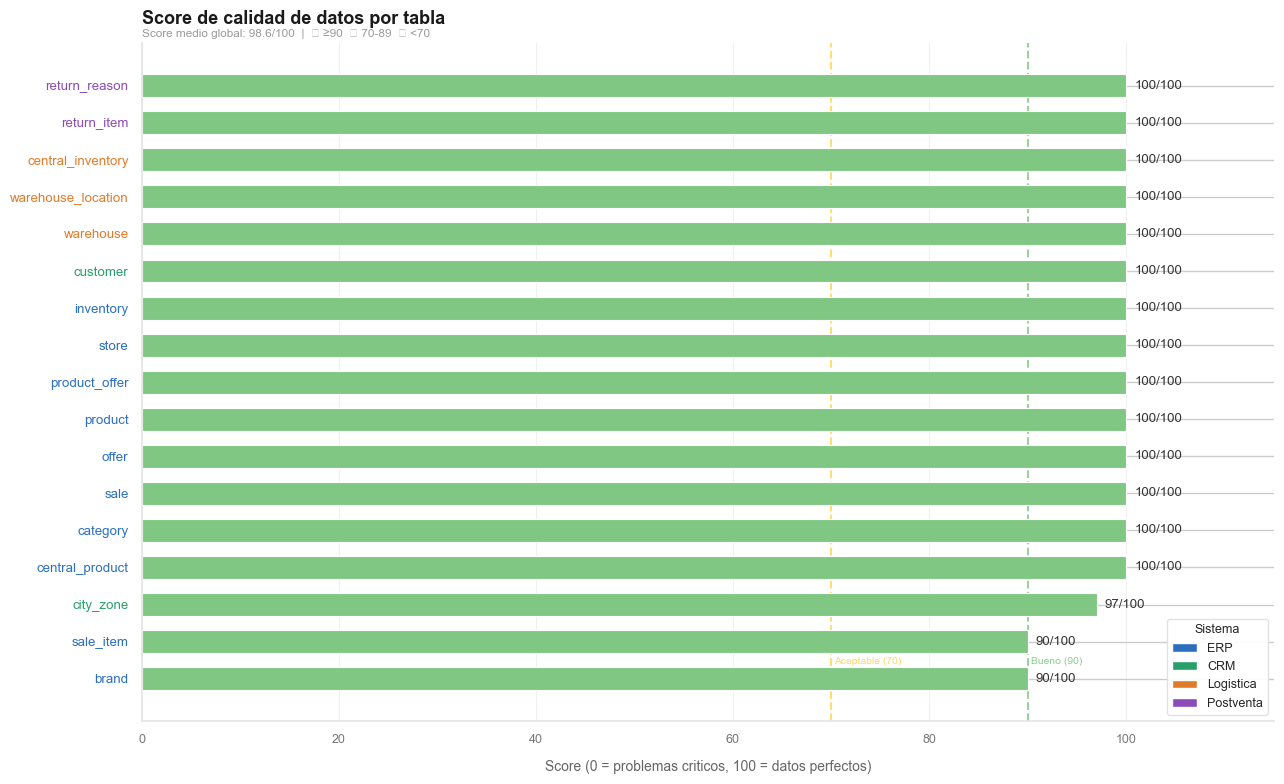


Seccion 3 completada - diagnostico de calidad de datos finalizado.


In [48]:
# ── Grafico: score de calidad por tabla ───────────────────────────────────────
df_scores_plot = df_scores.sort_values('score', ascending=True)
colores_score  = ['#E57373' if s < 70 else ('#FFD54F' if s < 90 else '#81C784')
                  for s in df_scores_plot['score']]

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('white')

bars = ax.barh(df_scores_plot['tabla'], df_scores_plot['score'],
               color=colores_score, edgecolor='white', linewidth=0.8, height=0.62)

for bar, val, sistema in zip(bars, df_scores_plot['score'], df_scores_plot['sistema']):
    ax.text(bar.get_width() + 0.8,
            bar.get_y() + bar.get_height() / 2,
            f'{val}/100',
            va='center', ha='left', fontsize=9.5, color='#333333', fontweight='500')

# Lineas de referencia
for umbral, color, label in [(70, '#FFD54F', 'Aceptable (70)'), (90, '#81C784', 'Bueno (90)')]:
    ax.axvline(umbral, color=color, linewidth=1.5, linestyle='--', zorder=0, alpha=0.8)
    ax.text(umbral + 0.3, 0.4, label, fontsize=7.5, color=color, alpha=0.9)

# Etiquetas del eje Y coloreadas por sistema
color_por_tabla = {t: PALETA[s] for s, ts in SISTEMAS.items() for t in ts}
for label, (_, row) in zip(ax.get_yticklabels(), df_scores_plot.iterrows()):
    label.set_color(color_por_tabla.get(row['tabla'], '#555555'))
    label.set_fontsize(9.5)

score_medio = df_scores['score'].mean()
ax.set_title('Score de calidad de datos por tabla', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01,
        f'Score medio global: {score_medio:.1f}/100  |  🟢 ≥90  🟡 70-89  🔴 <70',
        transform=ax.transAxes, fontsize=8.5, color='#999999')
ax.set_xlabel('Score (0 = problemas criticos, 100 = datos perfectos)',
              fontsize=10, color='#666666', labelpad=10)
ax.set_xlim(0, 115)
ax.tick_params(axis='x', labelsize=9, colors='#777777')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='#F0F0F0', linewidth=0.8)

legend_elements = [Patch(facecolor=PALETA[s], label=s) for s in PALETA]
ax.legend(handles=legend_elements, title='Sistema', title_fontsize=9,
          fontsize=9, loc='lower right', frameon=True, framealpha=0.95, edgecolor='#E0E0E0')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_score_calidad.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\nSeccion 3 completada - diagnostico de calidad de datos finalizado.')

In [49]:
query("""
    SELECT s.store_id, s.name, s.opened_date,
           MIN(sa.sale_date) AS primera_venta
    FROM store s
    JOIN sale sa ON s.store_id = sa.store_id
    GROUP BY s.store_id, s.name, s.opened_date
    ORDER BY s.store_id
""")

,store_id,name,opened_date,primera_venta
0,1,Store Retiro,2026-04-04,2020-01-01 16:18:28.792646
1,2,Store Salamanca,2026-04-04,2020-01-02 01:34:52.960372
2,3,Store Chamartín,2026-04-04,2020-01-01 09:54:18.514538
3,4,Store La Latina,2026-04-04,2020-01-04 12:10:37.202335
4,5,Store Sol,2026-04-04,2020-01-02 21:30:50.559972
5,6,Store Moncloa,2026-04-04,2020-01-06 08:22:41.243412
6,7,Store Atocha,2026-04-04,2020-01-04 01:58:46.194134
7,8,Store Vallecas,2026-04-04,2020-01-02 19:20:27.326600
8,9,Store Usera,2026-04-04,2020-01-04 06:36:14.559009
9,10,Store Carabanchel,2026-04-04,2020-01-01 03:41:35.198837


In [50]:
query("""
    SELECT sale_id, quantity, unit_price, subtotal,
           quantity * unit_price AS calculado,
           subtotal - (quantity * unit_price) AS diferencia
    FROM sale_item WHERE sale_id = 13009
""")

,sale_id,quantity,unit_price,subtotal,calculado,diferencia
0,13009,3,34.99,104.97,104.97,0.00
1,13009,1,29.99,26.99,29.99,-3.00
2,13009,2,99.90,189.81,199.80,-9.99
